# **Computational Urban Comfort Indexing and Annealed Optimisation for Latent Potentials**

**Authors:** Sijie Yang, Zdravko Trivic, Yihan Zhu, Mahmoud Abdelrahman, Filip Biljecki*

by Urban Analytics Lab, National University of Singapore

---

**Note:** Each .ipynb file can be run independently. This work is licensed under a [Creative Commons Attribution 4.0 International License](https://creativecommons.org/licenses/by/4.0/).

# UCI Part 1: Activity Comfort Field

This notebook includes two sections: definition of the **activity comfort field** and its parameter selection.

We need an **Activity Comfort Field** because grid-level **social activity comfort** (intensity × comfort sentiment from `code_1_social_activity_data`) can still be uneven, sparse in places, and sensitive to local noise. Smoothing aggregates nearby observations into a continuous spatial signal, preserves broad hotspots, and reduces random fluctuations so subsequent UCI modelling and optimisation are more stable and interpretable.

This notebook builds activity comfort field targets only, keeps geospatial features as original values, and exports a unified modelling GeoPackage.

Primary handover fields:
- Index for the location: `id`
- Social activity comfort columns **read from** `data_social_activity.gpkg`: `social_activity_comfort_eating`, …, `social_activity_comfort_sightseeing`
- Activity comfort field columns **saved to** `data_uci_modelling.gpkg`: `eating_field`, `nature_field`, `community_field`, `walking_field`, `sightseeing_field` (short names, aligned with `ACT_COLUMNS` in later notebooks)
- Geospatial feature columns: `SP_*`, `FC_*`, `AC_*`, `CD_*` (original feature values)
- Coordinates: `longitude`, `latitude`
- Geometry: `geometry`

Data sources used in this notebook:
- `data/data_social_activity.gpkg`
- `data/data_geospatial.gpkg`

Run the export code cell to save unified output to:
- `data/data_uci_modelling.gpkg`


## 1. Definition

At grid/location $\mathbf{u}$ for activity category $i$, **social activity comfort** combines posting intensity and category comfort sentiment (see `code_1_social_activity_data`):

$$
\text{SocialActivityComfort}_{i,\mathbf{u}} = \text{SocialActivityIntensity}_{i,\mathbf{u}} \times \text{AvgComfort}_{i,\mathbf{u}}.
$$

These values are stored in `social_activity_comfort_*` columns. Grid-level comfort can still be uneven, so we model neighborhood diffusion and spillover by defining an **Activity Comfort Field**:

$$
\widetilde{\text{ActivityComfortField}}_{i,\mathbf{u}} = \sum_{\mathbf{v} \in \mathcal{U}} K_\sigma\!\left(d(\mathbf{u},\mathbf{v})\right)\,\text{SocialActivityComfort}_{i,\mathbf{v}}
$$

where $K_\sigma(\cdot)$ is a Gaussian kernel and $d(\mathbf{u},\mathbf{v})$ is spatial distance. The kernel is:

$$
K_\sigma(r)=\frac{1}{\sqrt{2\pi}\sigma}\exp\!\left(-\frac{r^2}{2\sigma^2}\right),\quad r=d(\mathbf{u},\mathbf{v}).
$$

This implies that nearby grids (small $r$) receive larger weights, while distant grids decay exponentially in influence.

We then align the smoothed field back to the original **social activity comfort** distribution scale and enforce non-negativity:

$$
\text{ActivityComfortField}_{i,\mathbf{u}} = \max\left(0,\;\frac{\widetilde{\text{ActivityComfortField}}_{i,\mathbf{u}}-\mu_{\widetilde{i}}}{\sigma_{\widetilde{i}}+\varepsilon}\sigma_i+\mu_i\right).
$$

Here, $\mu_i,\sigma_i$ are the mean and standard deviation of the raw social activity comfort distribution for category $i$, $\mu_{\widetilde{i}},\sigma_{\widetilde{i}}$ are the corresponding statistics after field smoothing, and $\varepsilon$ is a numerical stability term.

Parameter settings used in this study (consistent with code):
- `grid_base = 500`: baseline grid resolution. The algorithm adaptively computes `(x_grid_size, y_grid_size)` from the longitude-latitude aspect ratio to preserve spatial shape.
- `sigma = 5.0`: Gaussian kernel standard deviation in **grid-cell units**. Larger $\sigma$ yields stronger spatial diffusion and broader field surfaces; smaller $\sigma$ preserves sharper local peaks.

Why this transformation is used:
- reduce sparsity and local noise in comfort signals;
- preserve neighborhood influence so the metric behaves as a spatial **activity comfort field** rather than isolated grid values;
- provide a more stable and interpretable exposure variable for downstream causal analysis.


In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy import ndimage
from sklearn.preprocessing import StandardScaler

# -------------------------
# Config
# -------------------------
FX_SOCIAL_FILE_PATH = "data/data_social_activity.gpkg"
FX_GEOSPATIAL_FILE_PATH = "data/data_geospatial.gpkg"
# Short category keys (field outputs: "{key}_field" — matches code_4 / code_6 ACT_COLUMNS)
FX_ACT_KEYS = ["eating", "nature", "community", "walking", "sightseeing"]
# Full column names as stored in data_social_activity.gpkg (inputs to smoothing)
FX_COMFORT_SOURCE_COLS = [f"social_activity_comfort_{k}" for k in FX_ACT_KEYS]
# Sensitivity / regression use raw comfort columns (full names)
FX_ACT_COLUMNS = FX_COMFORT_SOURCE_COLS
FX_DIMENSION_FEATURES = {
    "SP": ["SP_1-E_comfort", "SP_2-E_sunshine_intensity", "SP_3-E_temp_inference", "SP_4-E_humidity_inference", "SP_5-E_wind_inference", "SP_6-E_greenery_rate", "SP_7-E_shading_area", "SP_8-E_heat_source", "SP_9-E_traffic_flow", "SP_1-D_imageability", "SP_2-D_enclosure", "SP_3-D_human_scale", "SP_4-D_complexity"],
    "FC": ["FC_1-R_eating_rating", "FC_1-D_eating_density", "FC_2-R_retail_rating", "FC_2-D_retail_density", "FC_3-R_life_rating", "FC_3-D_life_density", "FC_4-R_recreation_rating", "FC_4-D_recreation_density", "FC_5-R_health_rating", "FC_5-D_health_density", "FC_6-R_community_rating", "FC_6-D_community_density", "FC_7-R_trans_rating", "FC_7-D_trans_density", "FC_1-H_HDB_density", "FC_1-G_review_polarity", "FC_2-G_review_subjectivity"],
    "AC": ["AC_1-L_closeness400", "AC_2-L_closeness800", "AC_1-G_closeness2000", "AC_2-G_closeness6000", "AC_1-T_subway_accessibility", "AC_2-T_subway_density", "AC_3-T_bus_accessibility", "AC_4-T_bus_density"],
    "CD": ["CD_1-P_population", "CD_1-B_building_density", "CD_1-L_leisure_density"],
}

# Baseline values used in code.ipynb
FX_BASE_GRID_BASE = 500
FX_BASE_SIGMA = 5.0


In [2]:
# -------------------------
# Core activity comfort field function (Gaussian smooth; aligned with original implementation)
# -------------------------
def fx_gaussian_grid_smooth(temp_df, target_col, grid_base=500, sigma=5.0):
    x_min, x_max = temp_df["longitude"].min(), temp_df["longitude"].max()
    y_min, y_max = temp_df["latitude"].min(), temp_df["latitude"].max()

    x_range = x_max - x_min
    y_range = y_max - y_min
    if x_range == 0 or y_range == 0:
        return temp_df[target_col].values.astype(float)

    aspect_ratio = x_range / y_range
    if aspect_ratio > 1:
        x_grid_size = int(grid_base)
        y_grid_size = max(2, int(grid_base / aspect_ratio))
    else:
        y_grid_size = int(grid_base)
        x_grid_size = max(2, int(grid_base * aspect_ratio))

    x_grid = np.linspace(x_min, x_max, x_grid_size)
    y_grid = np.linspace(y_min, y_max, y_grid_size)
    grid = np.zeros((y_grid_size, x_grid_size), dtype=float)

    for _, row in temp_df.iterrows():
        x_idx = int((row["longitude"] - x_min) / x_range * (x_grid_size - 1))
        y_idx = int((row["latitude"] - y_min) / y_range * (y_grid_size - 1))
        grid[y_idx, x_idx] += row[target_col]

    smoothed_grid = ndimage.gaussian_filter(grid, sigma=sigma)

    smoothed_values = []
    for _, row in temp_df.iterrows():
        x_idx = int((row["longitude"] - x_min) / x_range * (x_grid_size - 1))
        y_idx = int((row["latitude"] - y_min) / y_range * (y_grid_size - 1))
        smoothed_values.append(smoothed_grid[y_idx, x_idx])

    smoothed_values = np.asarray(smoothed_values, dtype=float)

    # Match raw distribution (mean/std)
    raw = temp_df[target_col].values.astype(float)
    raw_mean, raw_std = np.mean(raw), np.std(raw)
    sm_mean, sm_std = np.mean(smoothed_values), np.std(smoothed_values)

    if sm_std > 0:
        normalized = ((smoothed_values - sm_mean) / sm_std) * raw_std + raw_mean
    else:
        normalized = np.full_like(smoothed_values, fill_value=raw_mean)

    # Enforce nonnegative
    min_val = np.min(normalized)
    if min_val < 0:
        normalized = normalized - min_val

    return normalized


In [3]:
# -------------------------
# Data load + baseline extraction (activity comfort field + original features)
# -------------------------
fx_social_gdf = gpd.read_file(FX_SOCIAL_FILE_PATH)
fx_geo_gdf = gpd.read_file(FX_GEOSPATIAL_FILE_PATH)

for _gdf in [fx_social_gdf, fx_geo_gdf]:
    if _gdf.crs is None:
        _gdf.set_crs("EPSG:4326", inplace=True)
    elif _gdf.crs.to_string() != "EPSG:4326":
        _gdf.to_crs("EPSG:4326", inplace=True)

if "longitude" in fx_geo_gdf.columns and "latitude" in fx_geo_gdf.columns:
    fx_geo_gdf["longitude"] = fx_geo_gdf["longitude"].astype(float)
    fx_geo_gdf["latitude"] = fx_geo_gdf["latitude"].astype(float)
else:
    fx_geo_gdf["longitude"] = fx_geo_gdf.geometry.x.astype(float)
    fx_geo_gdf["latitude"] = fx_geo_gdf.geometry.y.astype(float)

social_cols = ["id"] + [c for c in FX_COMFORT_SOURCE_COLS if c in fx_social_gdf.columns]
missing_acts = [c for c in FX_COMFORT_SOURCE_COLS if c not in social_cols]
if missing_acts:
    raise RuntimeError(f"Missing social activity comfort columns in source: {missing_acts}")

fx_gdf = fx_geo_gdf.merge(fx_social_gdf[social_cols], on="id", how="inner")

fx_expected_features = sum(FX_DIMENSION_FEATURES.values(), [])
fx_available_features = [c for c in fx_expected_features if c in fx_gdf.columns]

# Build activity comfort field variables: read social_activity_comfort_* , write "{key}_field"
for key, src in zip(FX_ACT_KEYS, FX_COMFORT_SOURCE_COLS):
    temp_df = (
        fx_gdf[["longitude", "latitude", src]]
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=["longitude", "latitude", src])
        .copy()
    )
    fx_gdf.loc[temp_df.index, f"{key}_field"] = fx_gaussian_grid_smooth(
        temp_df,
        src,
        grid_base=FX_BASE_GRID_BASE,
        sigma=FX_BASE_SIGMA,
    )

fx_use_cols = (
    FX_COMFORT_SOURCE_COLS
    + fx_available_features
    + ["longitude", "latitude"]
    + [f"{k}_field" for k in FX_ACT_KEYS]
)

fx_df = (
    fx_gdf[fx_use_cols + ["geometry"]]
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=fx_use_cols + ["geometry"])
    .copy()
)
if fx_df.geometry.is_empty.any():
    fx_df = fx_df.loc[~fx_df.geometry.is_empty].copy()

fx_coords = np.column_stack([fx_df["longitude"].values, fx_df["latitude"].values])
fx_x_scaled_df = pd.DataFrame(
    StandardScaler().fit_transform(fx_df[fx_available_features].values),
    columns=fx_available_features,
    index=fx_df.index,
)

print(f"Social source: {FX_SOCIAL_FILE_PATH}")
print(f"Geospatial source: {FX_GEOSPATIAL_FILE_PATH}")
print(f"UCI modelling table ready: rows={len(fx_df)}, features={len(fx_available_features)}")
print(f"Baseline activity comfort field parameters: grid_base={FX_BASE_GRID_BASE}, sigma={FX_BASE_SIGMA}")


Social source: data/data_social_activity.gpkg
Geospatial source: data/data_geospatial.gpkg
UCI modelling table ready: rows=2096, features=41
Baseline activity comfort field parameters: grid_base=500, sigma=5.0


## 2. Integrated Sensitivity + Regression Evaluation for Parameter Selection

This section runs one continuous pipeline:
- Spatial sensitivity metrics (`corr`, `mae`, `top10_overlap`)
- Feature-based linear regression fit metrics (`r2`, `rmse`, `mae_reg`)
- Joint ranking and threshold-based final selection

All steps are executed in sequence without splitting into separate analysis sections.


### 2.1 Method Boundaries and Bias Risks

- **Platform and population bias**: social-media activity does not represent all demographic groups equally, so the activity comfort field should be interpreted as a proxy of observed digital activity (via comfort-weighted signals) rather than complete social participation.
- **Temporal sampling bias**: posting behavior varies by time-of-day, weekday/weekend, and events. If data are temporally imbalanced, the resulting field may overstate certain periods.
- **Field-transformation trade-off in sparse areas**: stronger diffusion can improve stability but may blur local heterogeneity and create over-diffused hotspots in low-sample regions.

These limits do not invalidate the method, but they should be explicitly considered when comparing places or deriving planning recommendations.


### 2.2 Explicit Parameter Selection Rule

The notebook computes a normalized joint score from Section 2B using the following weights:
- `corr_mean_norm`: 0.25 (higher is better)
- `hotspot_overlap_mean_norm`: 0.25 (higher is better)
- `r2_mean_norm`: 0.30 (higher is better)
- `rmse_mean_norm`: 0.10 (lower is better; inverted after normalization)
- `mae_reg_mean_norm`: 0.10 (lower is better; inverted after normalization)

Threshold screening in Section 2E is:
- `corr_mean >= 0.70`
- `hotspot_overlap_mean >= 0.50`
- `r2_mean >= 0.50`

Among qualified candidates, settings are sorted by `r2_mean` (descending), `overall_joint_score` (descending), `rmse_mean` (ascending), and `mae_reg_mean` (ascending).


In [4]:
# -------------------------
# 2A) Settings + helpers for sensitivity and regression
# -------------------------
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

SIGMA_CANDIDATES = [2.0, 3.0, 5.0, 7.0, 10.0]
GRID_BASE_CANDIDATES = [300, 500, 700]
TOP_FRAC = 0.10


def _safe_corr(a, b):
    if len(a) < 2:
        return np.nan
    a_std = np.std(a)
    b_std = np.std(b)
    if a_std == 0 or b_std == 0:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])


def _top_overlap_ratio(raw, ext, top_frac=0.10):
    n = len(raw)
    if n == 0:
        return np.nan
    k = max(1, int(np.ceil(n * top_frac)))
    raw_idx = np.argpartition(raw, -k)[-k:]
    ext_idx = np.argpartition(ext, -k)[-k:]
    overlap = len(set(raw_idx).intersection(set(ext_idx)))
    return overlap / k


def evaluate_one_setting(gdf, act_columns, sigma, grid_base):
    rows = []
    for act in act_columns:
        temp_df = (
            gdf[["longitude", "latitude", act]]
            .replace([np.inf, -np.inf], np.nan)
            .dropna(subset=["longitude", "latitude", act])
            .copy()
        )
        raw = temp_df[act].values.astype(float)
        ext = fx_gaussian_grid_smooth(temp_df, act, grid_base=grid_base, sigma=sigma)

        corr = _safe_corr(raw, ext)
        mae = float(np.mean(np.abs(ext - raw)))
        hotspot_overlap = _top_overlap_ratio(raw, ext, top_frac=TOP_FRAC)

        rows.append({
            "activity": act,
            "sigma": sigma,
            "grid_base": grid_base,
            "pearson_corr": corr,
            "mae": mae,
            "top10_overlap": hotspot_overlap,
        })
    return pd.DataFrame(rows)


def _build_xy_for_setting(gdf, activity, feature_cols, sigma, grid_base):
    cols = ["longitude", "latitude", activity] + feature_cols
    temp = (
        gdf[cols]
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=cols)
        .copy()
    )

    if len(temp) < 3:
        return None, None

    # Build activity comfort field target
    y = fx_gaussian_grid_smooth(
        temp[["longitude", "latitude", activity]],
        activity,
        grid_base=grid_base,
        sigma=sigma,
    )

    # Keep original feature values (no feature smoothing)
    X = temp[feature_cols].values.astype(float) if feature_cols else None
    return X, y


def evaluate_regression_one_setting(gdf, act_columns, feature_cols, sigma, grid_base):
    rows = []
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LinearRegression()),
    ])

    for act in act_columns:
        X, y = _build_xy_for_setting(gdf, act, feature_cols, sigma=sigma, grid_base=grid_base)
        if X is None:
            rows.append({"activity": act, "sigma": sigma, "grid_base": grid_base, "r2": np.nan, "rmse": np.nan, "mae_reg": np.nan})
            continue

        model.fit(X, y)
        pred = model.predict(X)
        rows.append({
            "activity": act,
            "sigma": sigma,
            "grid_base": grid_base,
            "r2": float(r2_score(y, pred)),
            "rmse": float(np.sqrt(mean_squared_error(y, pred))),
            "mae_reg": float(mean_absolute_error(y, pred)),
        })
    return pd.DataFrame(rows)


In [5]:
# -------------------------
# 2B) Run sensitivity + regression and build one joint table
# -------------------------
if len(fx_available_features) == 0:
    raise RuntimeError("No available features found for regression evaluation.")

sens_parts = []
reg_parts = []
for gb in GRID_BASE_CANDIDATES:
    for sg in SIGMA_CANDIDATES:
        sens_parts.append(evaluate_one_setting(fx_gdf, FX_ACT_COLUMNS, sigma=sg, grid_base=gb))
        reg_parts.append(evaluate_regression_one_setting(fx_gdf, FX_ACT_COLUMNS, fx_available_features, sigma=sg, grid_base=gb))

sens_df = pd.concat(sens_parts, ignore_index=True)
reg_df = pd.concat(reg_parts, ignore_index=True)

summary_df = (
    sens_df.groupby(["grid_base", "sigma"], as_index=False)
    .agg(
        corr_mean=("pearson_corr", "mean"),
        corr_std=("pearson_corr", "std"),
        mae_mean=("mae", "mean"),
        hotspot_overlap_mean=("top10_overlap", "mean"),
    )
)

reg_summary_df = (
    reg_df.groupby(["grid_base", "sigma"], as_index=False)
    .agg(
        r2_mean=("r2", "mean"),
        r2_std=("r2", "std"),
        rmse_mean=("rmse", "mean"),
        mae_reg_mean=("mae_reg", "mean"),
    )
)

joint_df = summary_df.merge(reg_summary_df, on=["grid_base", "sigma"], how="inner")

for m in ["corr_mean", "hotspot_overlap_mean", "r2_mean"]:
    mn, mx = joint_df[m].min(), joint_df[m].max()
    joint_df[f"{m}_norm"] = (joint_df[m] - mn) / (mx - mn) if mx > mn else 0.0

for m in ["mae_mean", "rmse_mean", "mae_reg_mean"]:
    mn, mx = joint_df[m].min(), joint_df[m].max()
    joint_df[f"{m}_norm"] = 1 - (joint_df[m] - mn) / (mx - mn) if mx > mn else 0.0

joint_df["overall_joint_score"] = (
    0.25 * joint_df["corr_mean_norm"]
    + 0.25 * joint_df["hotspot_overlap_mean_norm"]
    + 0.30 * joint_df["r2_mean_norm"]
    + 0.10 * joint_df["rmse_mean_norm"]
    + 0.10 * joint_df["mae_reg_mean_norm"]
)

joint_df = joint_df.sort_values(["grid_base", "sigma"]).reset_index(drop=True)
display(joint_df)


,grid_base,sigma,corr_mean,corr_std,mae_mean,hotspot_overlap_mean,r2_mean,r2_std,rmse_mean,mae_reg_mean,corr_mean_norm,hotspot_overlap_mean_norm,r2_mean_norm,mae_mean_norm,rmse_mean_norm,mae_reg_mean_norm,overall_joint_score
0,300,2.0,0.898993,0.006721,1.081432,0.760952,0.371318,0.148000,2.094761,1.450957,0.836275,0.695489,0.323262,0.703163,0.280066,0.255788,0.533505
1,300,3.0,0.717958,0.013328,1.929803,0.531429,0.506019,0.177604,1.824268,1.321642,0.536924,0.393484,0.580992,0.466819,0.528477,0.481117,0.507859
2,300,5.0,0.545808,0.041951,2.755759,0.371429,0.631051,0.184453,1.544446,1.162961,0.252263,0.182957,0.820222,0.236719,0.785455,0.757616,0.509179
3,300,7.0,0.463036,0.062804,3.215951,0.288571,0.686486,0.178558,1.408053,1.089120,0.115395,0.073935,0.926289,0.108516,0.910714,0.886282,0.504919
4,300,10.0,0.393250,0.075804,3.605476,0.232381,0.725011,0.168890,1.310829,1.023858,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.500000
5,500,2.0,0.997465,0.001258,0.082000,0.985714,0.214255,0.091141,2.379536,1.585215,0.999105,0.991228,0.022744,0.981591,0.018539,0.021846,0.508445
6,500,3.0,0.952640,0.002072,0.763339,0.854286,0.325170,0.133131,2.181781,1.479911,0.924983,0.818296,0.234963,0.791779,0.200150,0.205336,0.546857
7,500,5.0,0.721502,0.015526,1.933596,0.549524,0.510790,0.181056,1.812272,1.313990,0.542783,0.417293,0.590120,0.465762,0.539493,0.494450,0.520450
8,500,7.0,0.596491,0.032440,2.489580,0.431429,0.593691,0.188175,1.629145,1.212182,0.336071,0.261905,0.748739,0.310873,0.707671,0.671849,0.512068
9,500,10.0,0.498281,0.054346,3.011238,0.319048,0.661005,0.184911,1.469178,1.121696,0.173675,0.114035,0.877534,0.165546,0.854579,0.829519,0.503598


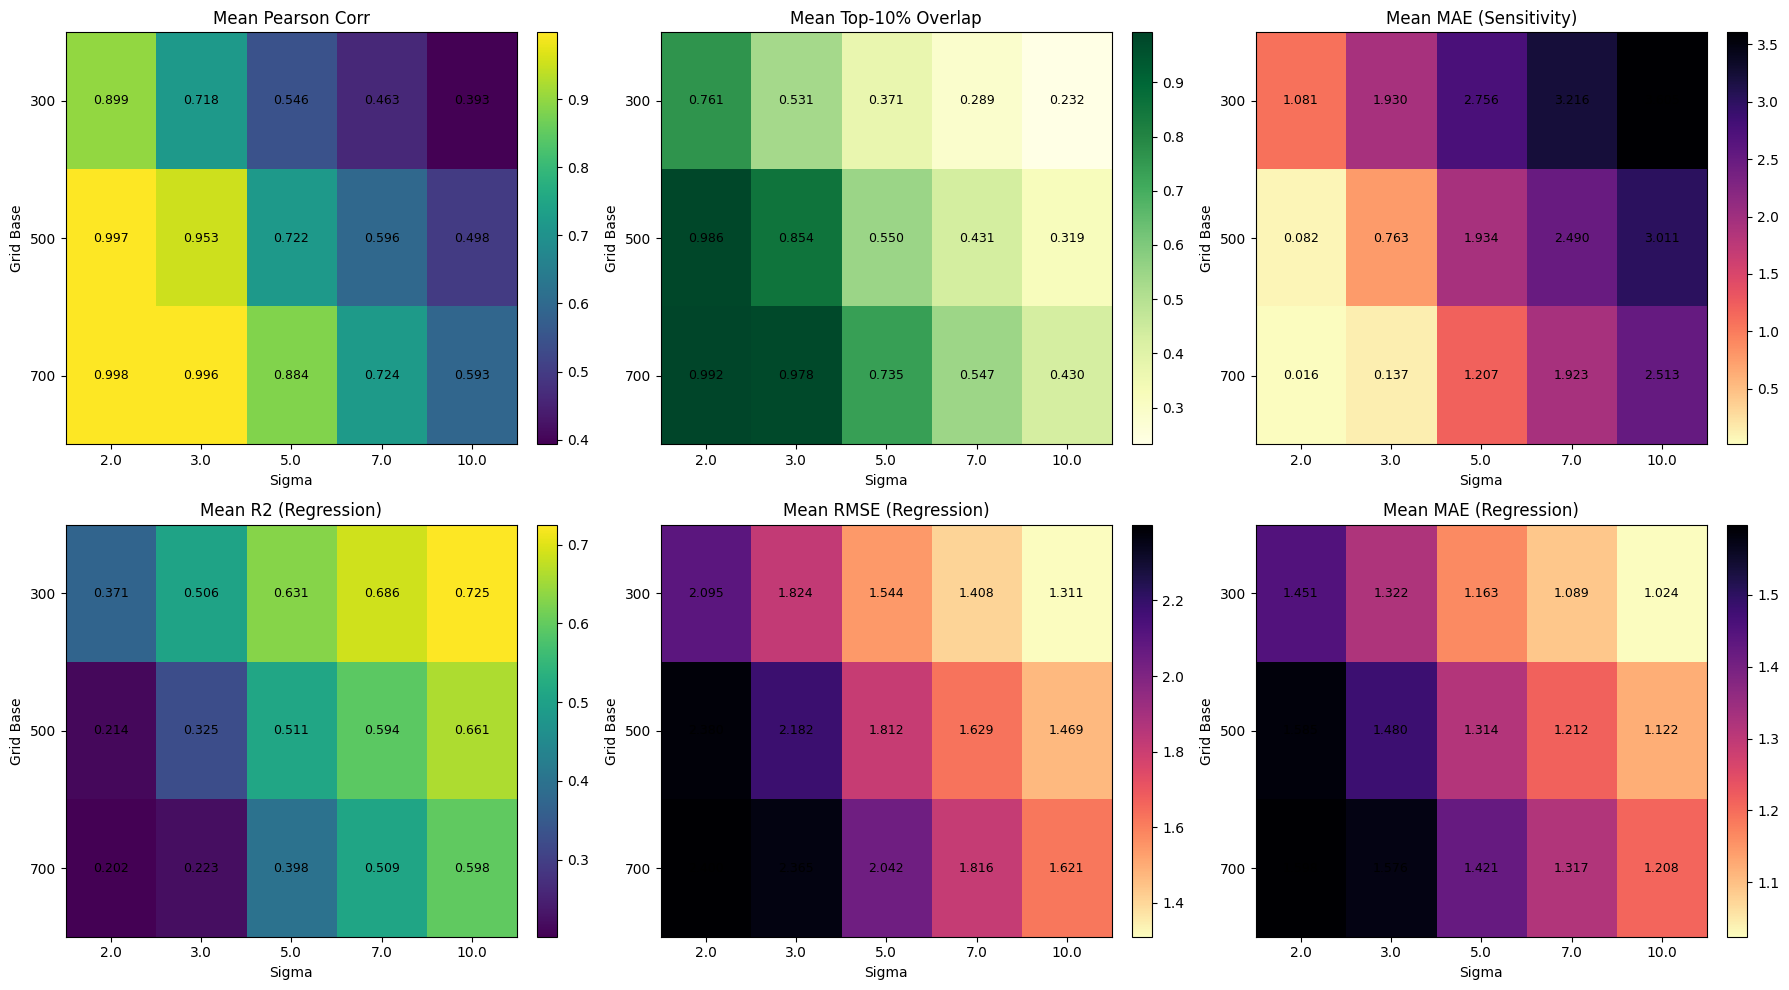

In [6]:
# -------------------------
# 2C) One visualization block (joint metrics heatmaps)
# -------------------------
viz_metrics = [
    ("corr_mean", "Mean Pearson Corr", "viridis"),
    ("hotspot_overlap_mean", "Mean Top-10% Overlap", "YlGn"),
    ("mae_mean", "Mean MAE (Sensitivity)", "magma_r"),
    ("r2_mean", "Mean R2 (Regression)", "viridis"),
    ("rmse_mean", "Mean RMSE (Regression)", "magma_r"),
    ("mae_reg_mean", "Mean MAE (Regression)", "magma_r"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (metric, title, cmap) in zip(axes, viz_metrics):
    mat = joint_df.pivot(index="grid_base", columns="sigma", values=metric).sort_index().sort_index(axis=1)
    arr = mat.values
    im = ax.imshow(arr, aspect="auto", cmap=cmap)

    ax.set_title(title)
    ax.set_xlabel("Sigma")
    ax.set_ylabel("Grid Base")
    ax.set_xticks(range(len(mat.columns)))
    ax.set_xticklabels([str(x) for x in mat.columns])
    ax.set_yticks(range(len(mat.index)))
    ax.set_yticklabels([str(y) for y in mat.index])

    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            ax.text(j, i, f"{arr[i, j]:.3f}", ha="center", va="center", fontsize=9)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


,grid_base,sigma,corr_mean,corr_std,mae_mean,hotspot_overlap_mean,r2_mean,r2_std,rmse_mean,mae_reg_mean,corr_mean_norm,hotspot_overlap_mean_norm,r2_mean_norm,mae_mean_norm,rmse_mean_norm,mae_reg_mean_norm,overall_joint_score
5,500,2.0,0.997465,0.001258,0.082000,0.985714,0.214255,0.091141,2.379536,1.585215,0.999105,0.991228,0.022744,0.981591,0.018539,0.021846,0.508445
6,500,3.0,0.952640,0.002072,0.763339,0.854286,0.325170,0.133131,2.181781,1.479911,0.924983,0.818296,0.234963,0.791779,0.200150,0.205336,0.546857
7,500,5.0,0.721502,0.015526,1.933596,0.549524,0.510790,0.181056,1.812272,1.313990,0.542783,0.417293,0.590120,0.465762,0.539493,0.494450,0.520450
8,500,7.0,0.596491,0.032440,2.489580,0.431429,0.593691,0.188175,1.629145,1.212182,0.336071,0.261905,0.748739,0.310873,0.707671,0.671849,0.512068
9,500,10.0,0.498281,0.054346,3.011238,0.319048,0.661005,0.184911,1.469178,1.121696,0.173675,0.114035,0.877534,0.165546,0.854579,0.829519,0.503598


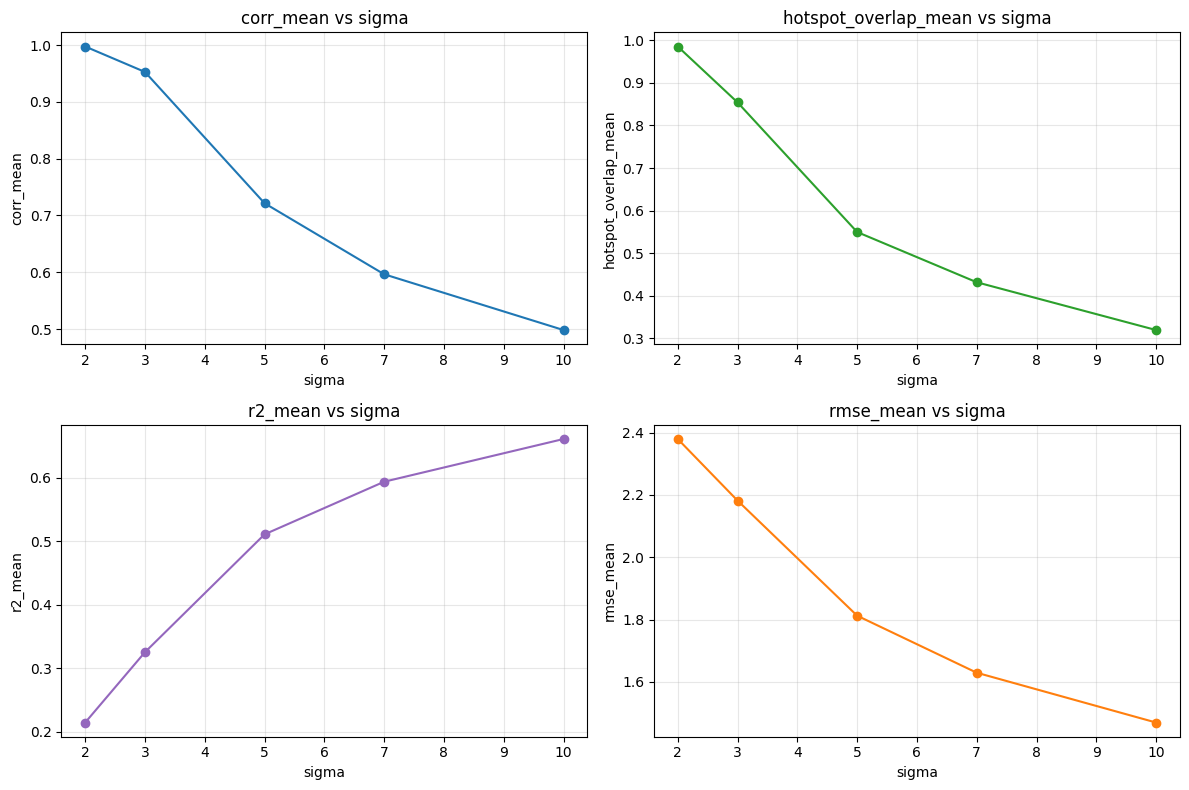

In [7]:
# -------------------------
# 2D) Focus view (grid_base = 500)
# -------------------------
FOCUS_GRID_BASE = 500
focus_df = joint_df[joint_df["grid_base"] == FOCUS_GRID_BASE].copy().sort_values("sigma")
display(focus_df)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(focus_df["sigma"], focus_df["corr_mean"], marker="o")
axes[0, 0].set_title("corr_mean vs sigma")
axes[0, 0].set_xlabel("sigma")
axes[0, 0].set_ylabel("corr_mean")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(focus_df["sigma"], focus_df["hotspot_overlap_mean"], marker="o", color="tab:green")
axes[0, 1].set_title("hotspot_overlap_mean vs sigma")
axes[0, 1].set_xlabel("sigma")
axes[0, 1].set_ylabel("hotspot_overlap_mean")
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(focus_df["sigma"], focus_df["r2_mean"], marker="o", color="tab:purple")
axes[1, 0].set_title("r2_mean vs sigma")
axes[1, 0].set_xlabel("sigma")
axes[1, 0].set_ylabel("r2_mean")
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(focus_df["sigma"], focus_df["rmse_mean"], marker="o", color="tab:orange")
axes[1, 1].set_title("rmse_mean vs sigma")
axes[1, 1].set_xlabel("sigma")
axes[1, 1].set_ylabel("rmse_mean")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [8]:
# -------------------------
# 2E) Final recommendation (threshold-based)
# -------------------------
THR_CORR = 0.70
THR_HOTSPOT = 0.50
THR_R2 = 0.50

joint_filtered = joint_df[
    (joint_df["corr_mean"] >= THR_CORR)
    & (joint_df["hotspot_overlap_mean"] >= THR_HOTSPOT)
    & (joint_df["r2_mean"] >= THR_R2)
].copy()

joint_filtered = joint_filtered.sort_values(
    ["r2_mean", "overall_joint_score", "rmse_mean", "mae_reg_mean"],
    ascending=[False, False, True, True],
)

print(f"Thresholds: corr_mean>={THR_CORR}, hotspot_overlap_mean>={THR_HOTSPOT}, r2_mean>={THR_R2}")
print(f"Candidates after thresholding: {len(joint_filtered)}")
display(joint_filtered)

if len(joint_filtered) > 0:
    best = joint_filtered.iloc[0][["grid_base", "sigma", "corr_mean", "hotspot_overlap_mean", "r2_mean", "overall_joint_score"]]
    print("Final recommended setting:")
    display(best.to_frame().T)
else:
    print("No setting satisfies all thresholds. Consider relaxing thresholds.")


Thresholds: corr_mean>=0.7, hotspot_overlap_mean>=0.5, r2_mean>=0.5
Candidates after thresholding: 3


,grid_base,sigma,corr_mean,corr_std,mae_mean,hotspot_overlap_mean,r2_mean,r2_std,rmse_mean,mae_reg_mean,corr_mean_norm,hotspot_overlap_mean_norm,r2_mean_norm,mae_mean_norm,rmse_mean_norm,mae_reg_mean_norm,overall_joint_score
7,500,5.0,0.721502,0.015526,1.933596,0.549524,0.510790,0.181056,1.812272,1.313990,0.542783,0.417293,0.590120,0.465762,0.539493,0.494450,0.520450
13,700,7.0,0.723733,0.014967,1.923385,0.546667,0.509354,0.181660,1.815654,1.317240,0.546473,0.413534,0.587373,0.468607,0.536388,0.488788,0.518731
1,300,3.0,0.717958,0.013328,1.929803,0.531429,0.506019,0.177604,1.824268,1.321642,0.536924,0.393484,0.580992,0.466819,0.528477,0.481117,0.507859


Final recommended setting:


,grid_base,sigma,corr_mean,hotspot_overlap_mean,r2_mean,overall_joint_score
7,500.0,5.0,0.721502,0.549524,0.51079,0.52045


## 3. Activity Comfort Field Visualization

This block compares grid-level **social activity comfort** (raw inputs) and the smoothed **activity comfort field** for each category, including map views and raw-vs-field scatter diagnostics.


/var/folders/f4/33sk92_n60j6tssngt9ntw3m0000gn/T/ipykernel_30672/339407695.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.06, 1, 1])


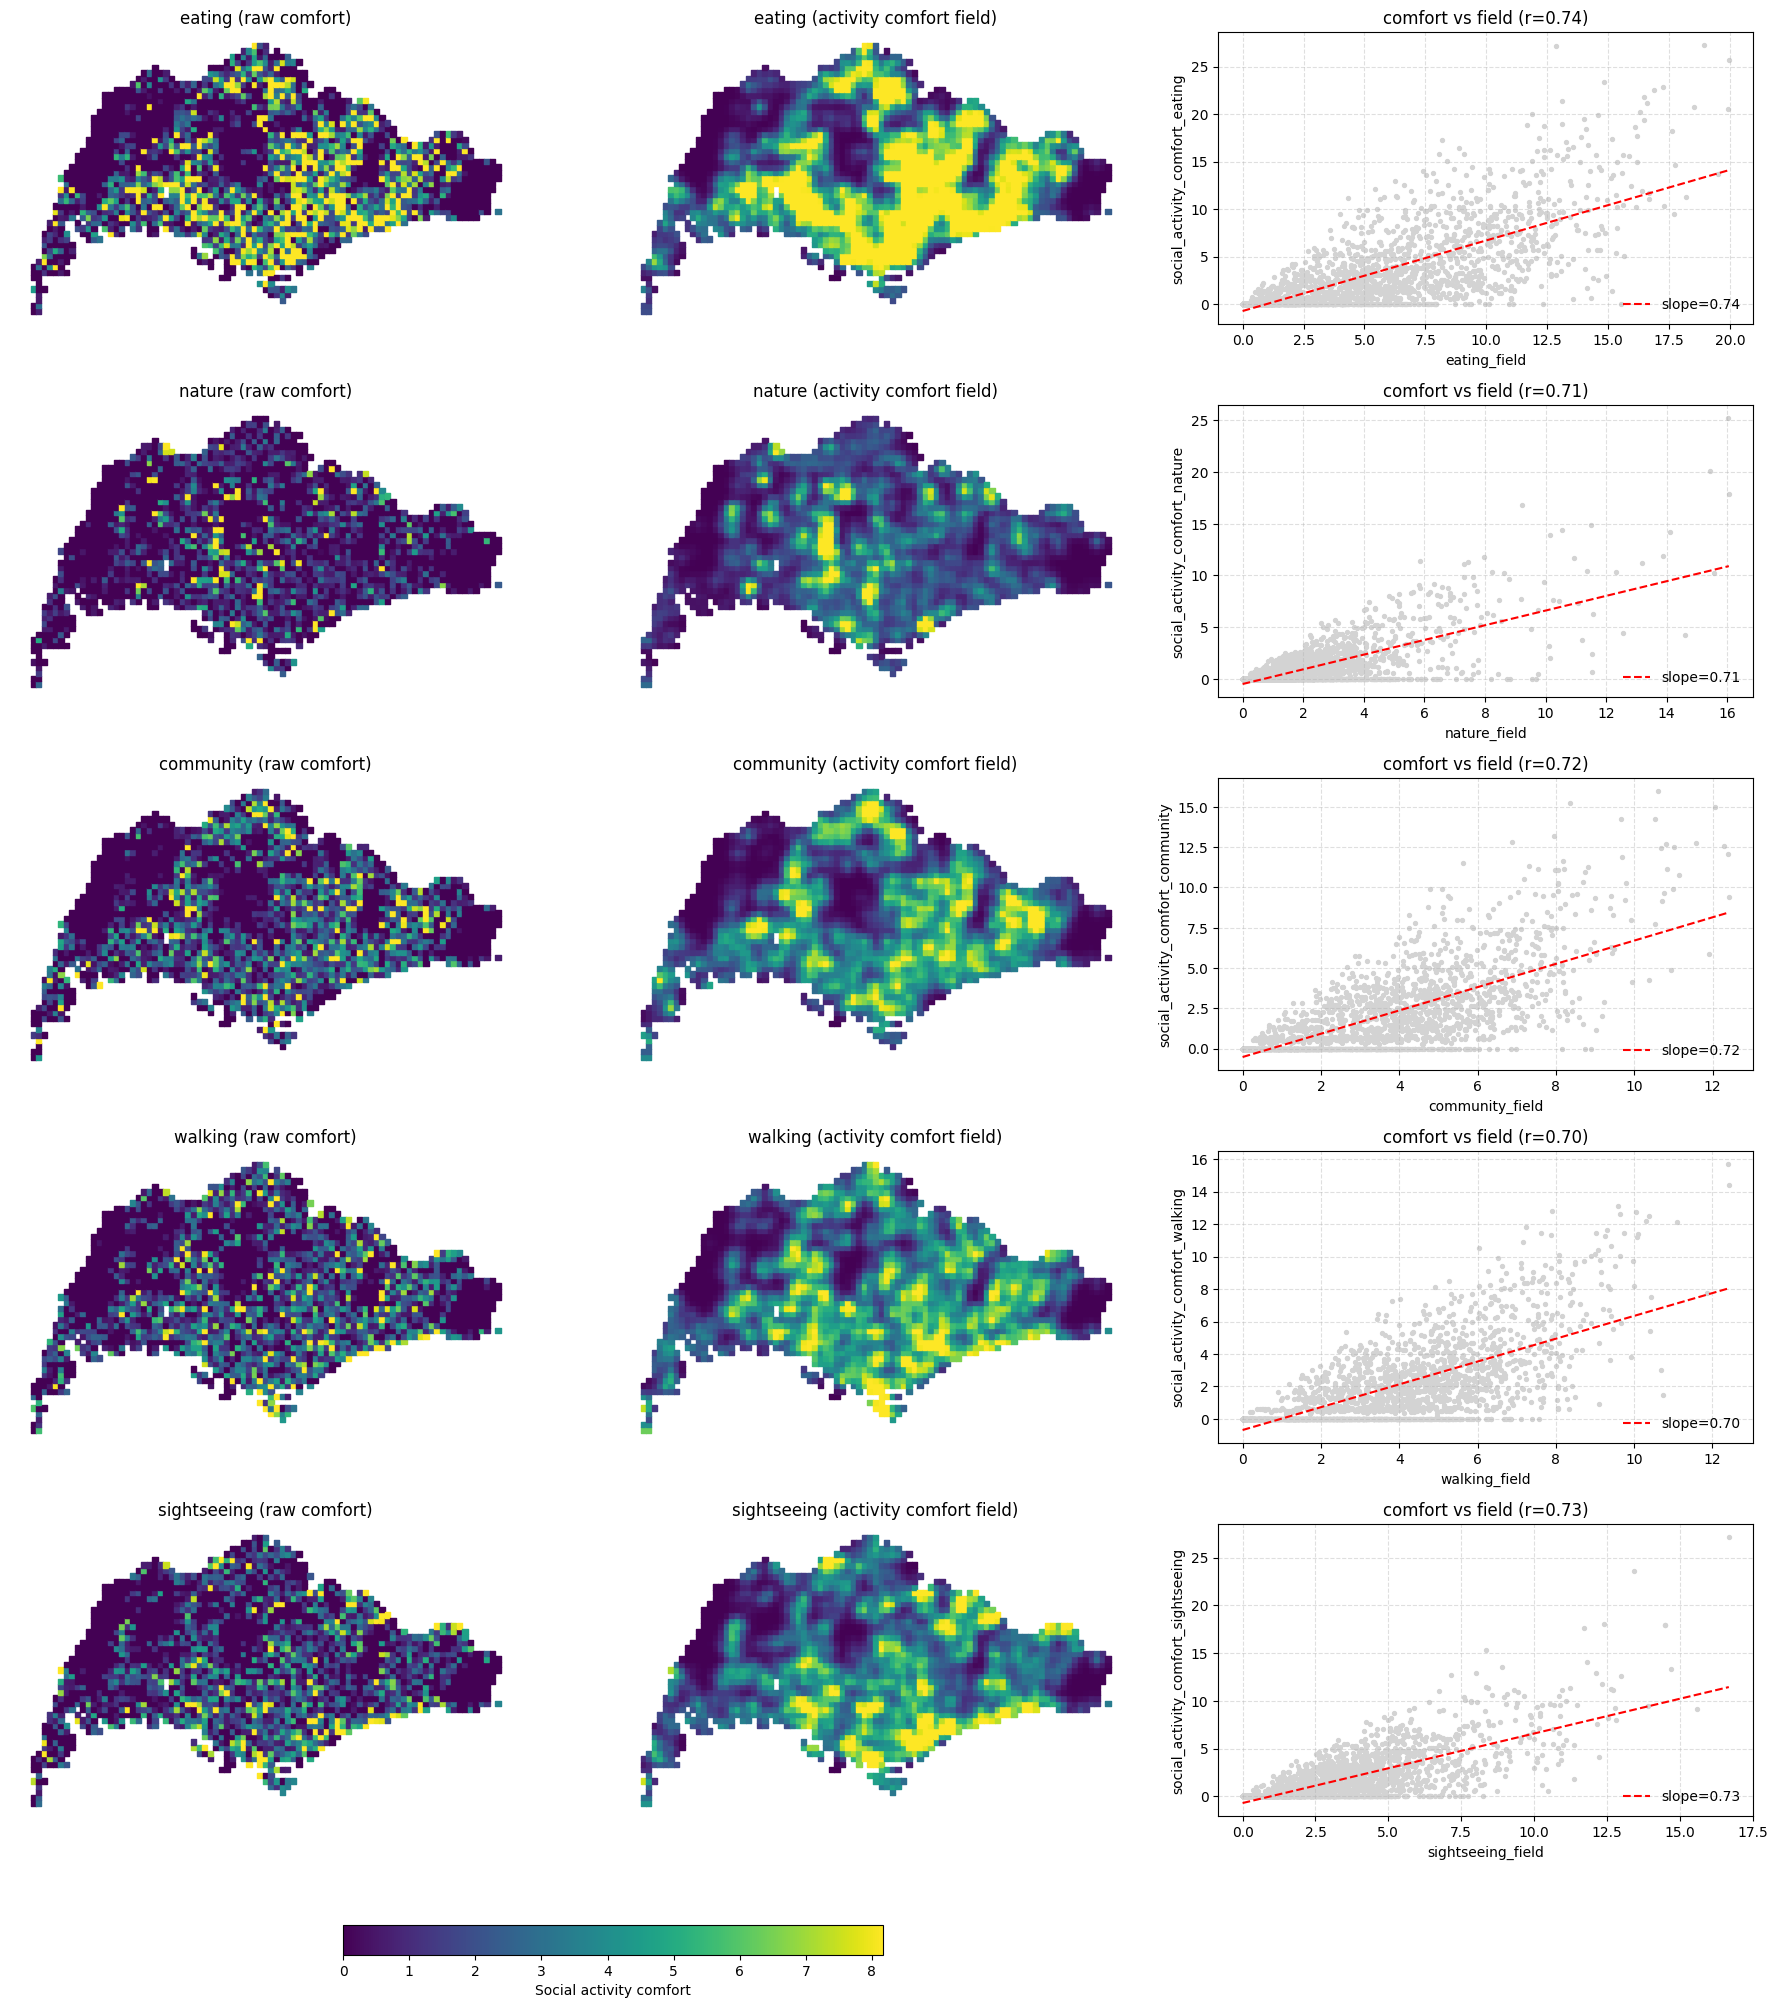

Social activity comfort (raw) and activity comfort field column list:
['social_activity_comfort_eating', 'social_activity_comfort_nature', 'social_activity_comfort_community', 'social_activity_comfort_walking', 'social_activity_comfort_sightseeing', 'eating_field', 'nature_field', 'community_field', 'walking_field', 'sightseeing_field']
===== Raw social activity comfort (value description) =====
social_activity_comfort_eating (raw comfort) describe():
count    2096.000000
mean        2.990343
std         4.129351
min         0.000000
25%         0.000000
50%         1.299211
75%         4.440931
max        27.238879
Name: social_activity_comfort_eating, dtype: float64
social_activity_comfort_nature (raw comfort) describe():
count    2096.000000
mean        1.075958
std         2.058273
min         0.000000
25%         0.000000
50%         0.000000
75%         1.337765
max        25.199294
Name: social_activity_comfort_nature, dtype: float64
social_activity_comfort_community (raw comfor

In [9]:
# -------------------------
# 3A) Activity comfort field: raw social activity comfort vs smoothed field
# -------------------------
import matplotlib.pyplot as plt
import matplotlib as mpl

if "fx_df" not in globals():
    raise RuntimeError("Please run the activity comfort field extraction block first.")

missing_field = [k for k in FX_ACT_KEYS if f"{k}_field" not in fx_df.columns]
if missing_field:
    raise RuntimeError(f"Missing field columns: {missing_field}. Re-run the activity comfort field block.")

n_acts = len(FX_ACT_KEYS)
fig, axes = plt.subplots(n_acts, 3, figsize=(18, 4 * n_acts))
if n_acts == 1:
    axes = np.array([axes])

# Shared color scale for raw comfort vs activity comfort field maps
all_vals = []
for src, k in zip(FX_COMFORT_SOURCE_COLS, FX_ACT_KEYS):
    all_vals.extend(fx_df[src].values.tolist())
    all_vals.extend(fx_df[f"{k}_field"].values.tolist())
vmin = float(np.nanmin(all_vals))
vmax = float(np.nanmax(all_vals)) * 0.3 # Set a cap for clear visualisation

for r, (k, src) in enumerate(zip(FX_ACT_KEYS, FX_COMFORT_SOURCE_COLS)):
    raw_col = src
    sm_col = f"{k}_field"

    ax_raw, ax_smooth, ax_scatter = axes[r, 0], axes[r, 1], axes[r, 2]

    fx_df.plot(
        ax=ax_raw,
        column=raw_col,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        marker="s",
        markersize=15,
        legend=False,
    )
    ax_raw.set_title(f"{k} (raw comfort)")
    ax_raw.set_axis_off()

    fx_df.plot(
        ax=ax_smooth,
        column=sm_col,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        marker="s",
        markersize=15,
        legend=False,
    )
    ax_smooth.set_title(f"{k} (activity comfort field)")
    ax_smooth.set_axis_off()

    x = fx_df[sm_col].values
    y = fx_df[raw_col].values
    ax_scatter.scatter(x, y, color="lightgrey", s=8)
    b, a = np.polyfit(x, y, 1)
    xx = np.linspace(np.nanmin(x), np.nanmax(x), 100)
    ax_scatter.plot(xx, a + b * xx, "r--", linewidth=1.5, label=f"slope={b:.2f}")
    corr = np.corrcoef(x, y)[0, 1]
    ax_scatter.set_title(f"comfort vs field (r={corr:.2f})")
    ax_scatter.set_xlabel(f"{k}_field")
    ax_scatter.set_ylabel(src)
    ax_scatter.grid(True, linestyle="--", alpha=0.4)
    ax_scatter.legend(loc="lower right", frameon=False)

norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])

# Put colorbar at the very bottom to avoid overlap with scatter panels
fig.subplots_adjust(bottom=0.08)
cbar_ax = fig.add_axes([0.2, 0.02, 0.3, 0.015])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Social activity comfort")

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

print("Social activity comfort (raw) and activity comfort field column list:")
print(FX_COMFORT_SOURCE_COLS + [f"{k}_field" for k in FX_ACT_KEYS])

# Print value descriptions for raw and extracted data
print("===== Raw social activity comfort (value description) =====")
for src in FX_COMFORT_SOURCE_COLS:
    print(f"{src} (raw comfort) describe():")
    print(fx_df[src].describe())

print("===== Activity comfort field (value description) =====")
for k in FX_ACT_KEYS:
    print(f"{k}_field describe():")
    print(fx_df[f'{k}_field'].describe())



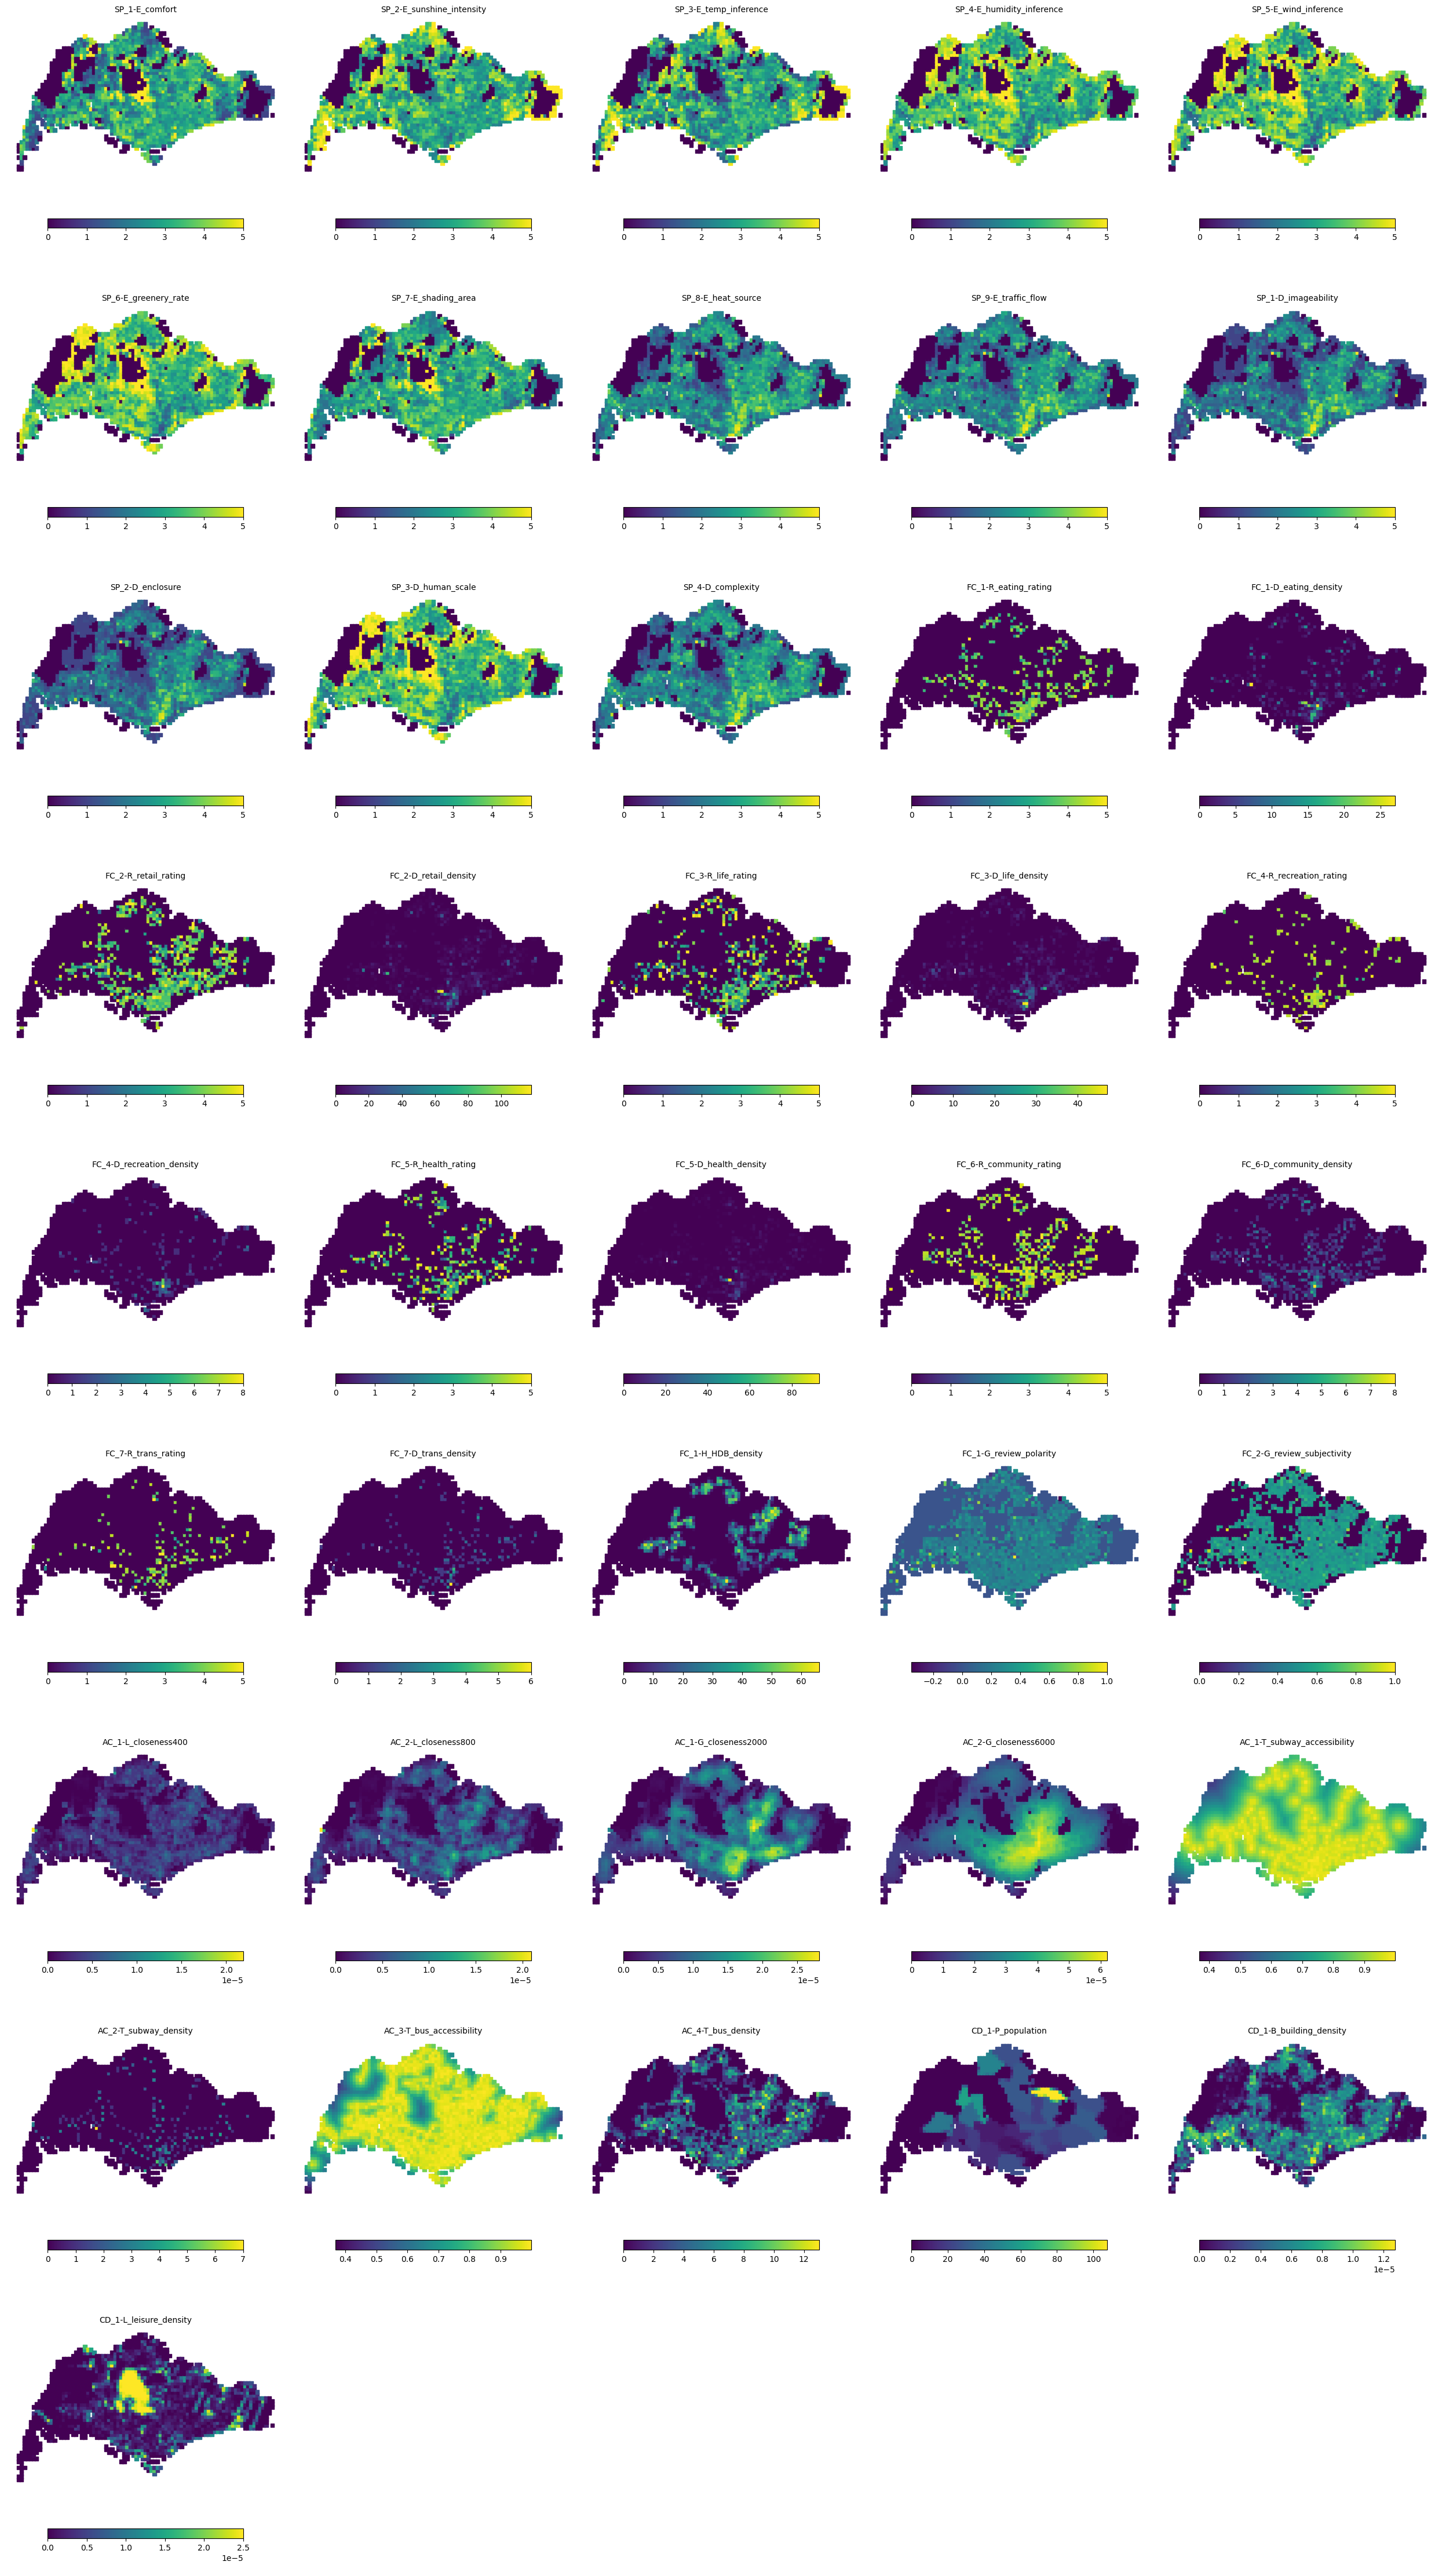

Visualized features: 41


In [10]:
# -------------------------
# 3B) Feature visualization (all features, single-pass)
# -------------------------

if "fx_df" not in globals():
    raise RuntimeError("Please run the activity comfort field extraction block first.")

feature_cols = [c for c in fx_available_features if c in fx_df.columns]
if not feature_cols:
    raise RuntimeError("No feature columns found for visualization.")

n_cols = 5
n_rows = int(len(feature_cols) / n_cols) + (len(feature_cols) % n_cols > 0)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))

for i, col in enumerate(feature_cols):
    ax = axes.flat[i]
    fx_df.plot(
        ax=ax,
        column=col,
        marker="s",
        markersize=22,
        legend=True,
        cmap="viridis",
        legend_kwds={"orientation": "horizontal", "shrink": 0.7},
    )
    ax.set_title(col, fontsize=10)
    ax.axis("off")

for j in range(i + 1, n_rows * n_cols):
    axes.flat[j].axis("off")

plt.tight_layout()
plt.show()

print(f"Visualized features: {len(feature_cols)}")


In [11]:
# -------------------------
# 3C) Export activity comfort field + original features to GPKG
# -------------------------
from pathlib import Path

FX_EXPORT_DIR = Path("data")
FX_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
FX_EXPORT_GPKG = FX_EXPORT_DIR / "data_uci_modelling.gpkg"

field_cols = [f"{k}_field" for k in FX_ACT_KEYS if f"{k}_field" in fx_gdf.columns]
feature_cols = [f for f in fx_available_features if f in fx_gdf.columns]

fx_export_cols = ["id", "longitude", "latitude"] + field_cols + feature_cols + ["geometry"]
fx_export_cols = [c for c in fx_export_cols if c in fx_gdf.columns]

if len(field_cols) == 0 or len(feature_cols) == 0:
    raise RuntimeError("Missing activity comfort field columns or feature columns. Please run the extraction cells first.")

fx_export_gdf = fx_gdf[fx_export_cols].copy()
fx_export_gdf.to_file(FX_EXPORT_GPKG, driver="GPKG")

print(f"Exported: {FX_EXPORT_GPKG}")
print(f"Rows: {len(fx_export_gdf)}, Columns: {len(fx_export_gdf.columns)}")
print(f"Features: {len(feature_cols)}, Activity comfort fields: {len(field_cols)}")
print("Exported columns:")
for col in fx_export_cols:
    print(f"  {col}")


Exported: data/data_uci_modelling.gpkg
Rows: 2096, Columns: 50
Features: 41, Activity comfort fields: 5
Exported columns:
  id
  longitude
  latitude
  eating_field
  nature_field
  community_field
  walking_field
  sightseeing_field
  SP_1-E_comfort
  SP_2-E_sunshine_intensity
  SP_3-E_temp_inference
  SP_4-E_humidity_inference
  SP_5-E_wind_inference
  SP_6-E_greenery_rate
  SP_7-E_shading_area
  SP_8-E_heat_source
  SP_9-E_traffic_flow
  SP_1-D_imageability
  SP_2-D_enclosure
  SP_3-D_human_scale
  SP_4-D_complexity
  FC_1-R_eating_rating
  FC_1-D_eating_density
  FC_2-R_retail_rating
  FC_2-D_retail_density
  FC_3-R_life_rating
  FC_3-D_life_density
  FC_4-R_recreation_rating
  FC_4-D_recreation_density
  FC_5-R_health_rating
  FC_5-D_health_density
  FC_6-R_community_rating
  FC_6-D_community_density
  FC_7-R_trans_rating
  FC_7-D_trans_density
  FC_1-H_HDB_density
  FC_1-G_review_polarity
  FC_2-G_review_subjectivity
  AC_1-L_closeness400
  AC_2-L_closeness800
  AC_1-G_closeness2